## 1. Dataset & Classification
The Kaggle FinTech dataset can be loaded in the optional cell below (upload the CSV to Colab first). So that the notebook always runs top-to-bottom, the default is a hand-built DataFrame of 32 real FinTech companies and their primary service.

# Week 1: FinTech Taxonomy & the Pakistani Ecosystem
**Course:** FinTech (AF 705), MS Finance, Air University  
**Name / Roll No.:** Robaan Azhar (2503955)

This notebook loads a FinTech-companies table, classifies 32 companies into the 7-category taxonomy, compares them with Pakistani apps, and plots category counts.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# OPTIONAL: load your Kaggle CSV instead (upload it to Colab, then uncomment)
# df = pd.read_csv("fintech_companies.csv")

data = [
 # company, HQ country, primary service, taxonomy category
 ("PayPal","USA","Online payments & wallet","Payments & Digital Wallets"),
 ("Stripe","USA","Payment processing APIs","Payments & Digital Wallets"),
 ("Block (Square)","USA","Merchant payments & POS","Payments & Digital Wallets"),
 ("Adyen","Netherlands","Payment processing","Payments & Digital Wallets"),
 ("Wise","UK","Cross-border money transfer","Payments & Digital Wallets"),
 ("Paytm","India","Mobile wallet & UPI payments","Payments & Digital Wallets"),
 ("Alipay (Ant Group)","China","Mobile wallet","Payments & Digital Wallets"),
 ("Venmo","USA","Peer-to-peer payments","Payments & Digital Wallets"),
 ("Revolut","UK","Mobile-first bank account","Digital Banking & Neobanks"),
 ("Monzo","UK","Mobile-only bank","Digital Banking & Neobanks"),
 ("N26","Germany","Mobile-only bank","Digital Banking & Neobanks"),
 ("Chime","USA","Neobank accounts","Digital Banking & Neobanks"),
 ("Nubank","Brazil","Digital bank & cards","Digital Banking & Neobanks"),
 ("Affirm","USA","Buy-now-pay-later","Lending Tech & BNPL"),
 ("Klarna","Sweden","Buy-now-pay-later","Lending Tech & BNPL"),
 ("Upstart","USA","AI-based personal loans","Lending Tech & BNPL"),
 ("LendingClub","USA","Peer-to-peer lending marketplace","Lending Tech & BNPL"),
 ("Zip","Australia","Buy-now-pay-later","Lending Tech & BNPL"),
 ("Betterment","USA","Robo-advisor","WealthTech & Robo-Advisory"),
 ("Wealthfront","USA","Robo-advisor","WealthTech & Robo-Advisory"),
 ("Robinhood","USA","Commission-free investing app","WealthTech & Robo-Advisory"),
 ("Acorns","USA","Micro-investing","WealthTech & Robo-Advisory"),
 ("Lemonade","USA","AI-driven home/renters insurance","InsurTech"),
 ("Root","USA","Telematics car insurance","InsurTech"),
 ("Oscar Health","USA","Tech-driven health insurance","InsurTech"),
 ("Coinbase","USA","Crypto exchange","Blockchain & Crypto"),
 ("Binance","Global","Crypto exchange","Blockchain & Crypto"),
 ("Ripple","USA","Blockchain payment protocol (XRP)","Blockchain & Crypto"),
 ("Kraken","USA","Crypto exchange","Blockchain & Crypto"),
 ("Chainalysis","USA","Blockchain compliance analytics","RegTech"),
 ("ComplyAdvantage","UK","AML screening","RegTech"),
 ("Onfido","UK","Digital identity verification (KYC)","RegTech"),
]
df = pd.DataFrame(data, columns=["Company","HQ_Country","Primary_Service","Taxonomy_Category"])
print(df.shape)
df.head(10)

(32, 4)


,Company,HQ_Country,Primary_Service,Taxonomy_Category
0,PayPal,USA,Online payments & wallet,Payments & Digital Wallets
1,Stripe,USA,Payment processing APIs,Payments & Digital Wallets
2,Block (Square),USA,Merchant payments & POS,Payments & Digital Wallets
3,Adyen,Netherlands,Payment processing,Payments & Digital Wallets
4,Wise,UK,Cross-border money transfer,Payments & Digital Wallets
5,Paytm,India,Mobile wallet & UPI payments,Payments & Digital Wallets
6,Alipay (Ant Group),China,Mobile wallet,Payments & Digital Wallets
7,Venmo,USA,Peer-to-peer payments,Payments & Digital Wallets
8,Revolut,UK,Mobile-first bank account,Digital Banking & Neobanks
9,Monzo,UK,Mobile-only bank,Digital Banking & Neobanks


In [ ]:
# Quick checks: every row classified into one of the 7 taxonomy categories
TAXONOMY = ["Payments & Digital Wallets","Digital Banking & Neobanks","Lending Tech & BNPL",
            "WealthTech & Robo-Advisory","InsurTech","Blockchain & Crypto","RegTech"]
assert df["Taxonomy_Category"].isin(TAXONOMY).all()
assert len(df) >= 25
df

,Company,HQ_Country,Primary_Service,Taxonomy_Category
0,PayPal,USA,Online payments & wallet,Payments & Digital Wallets
1,Stripe,USA,Payment processing APIs,Payments & Digital Wallets
2,Block (Square),USA,Merchant payments & POS,Payments & Digital Wallets
3,Adyen,Netherlands,Payment processing,Payments & Digital Wallets
4,Wise,UK,Cross-border money transfer,Payments & Digital Wallets
5,Paytm,India,Mobile wallet & UPI payments,Payments & Digital Wallets
6,Alipay (Ant Group),China,Mobile wallet,Payments & Digital Wallets
7,Venmo,USA,Peer-to-peer payments,Payments & Digital Wallets
8,Revolut,UK,Mobile-first bank account,Digital Banking & Neobanks
9,Monzo,UK,Mobile-only bank,Digital Banking & Neobanks


### Classification justification (3 non-obvious cases)
1. **Klarna → Lending Tech & BNPL (not Payments).** Klarna is used at checkout like a payment method, but its core economic activity is extending short-term credit to the shopper and earning from merchant fees and credit risk. Credit provision is the defining function, so it belongs in Lending/BNPL.
2. **Robinhood → WealthTech (not Payments or Crypto).** It offers crypto trading, but its main product is commission-free stock and options investing for retail users. The core service is investing/wealth access, so WealthTech fits best.
3. **Chainalysis → RegTech (not Blockchain & Crypto).** It works entirely on blockchain data, but its customers (exchanges, banks, regulators) buy it for compliance, AML and investigations. It serves a regulatory need rather than offering crypto products, so RegTech is the better label.

## 2. Pakistani Apps Comparison Table

In [ ]:
pk = pd.DataFrame([
 ("NayaPay","Payments & Digital Wallets","SBP-licensed e-money institution; app-based wallet and account with Raast connectivity"),
 ("SadaPay","Payments & Digital Wallets","SBP-licensed e-money institution; app-based account with a debit card"),
 ("JazzCash","Payments & Digital Wallets","Mobile wallet from the Jazz telecom network; widely used for bill payments and agent cash-in/out"),
 ("Easypaisa","Digital Banking & Neobanks","Pakistan's first mobile-money service (2009); now Easypaisa Bank, one of the SBP-licensed digital banks"),
 ("Mashreq Bank Pakistan","Digital Banking & Neobanks","Licensed digital bank backed by UAE's Mashreq Bank"),
 ("HugoBank","Digital Banking & Neobanks","One of the five SBP-licensed digital banks"),
 ("RAAST","Payments & Digital Wallets","SBP-owned instant payment system; about 48 million users and nearly Rs 50 trillion processed in 2025"),
 ("Finja","Lending Tech & BNPL","Pakistani digital lending platform for small businesses and consumers"),
], columns=["App / Platform","Taxonomy Category","Distinguishing Feature / Fact"])
pk

,App / Platform,Taxonomy Category,Distinguishing Feature / Fact
0,NayaPay,Payments & Digital Wallets,SBP-licensed e-money institution; app-based wa...
1,SadaPay,Payments & Digital Wallets,SBP-licensed e-money institution; app-based ac...
2,JazzCash,Payments & Digital Wallets,Mobile wallet from the Jazz telecom network; w...
3,Easypaisa,Digital Banking & Neobanks,Pakistan's first mobile-money service (2009); ...
4,Mashreq Bank Pakistan,Digital Banking & Neobanks,Licensed digital bank backed by UAE's Mashreq ...
5,HugoBank,Digital Banking & Neobanks,One of the five SBP-licensed digital banks
6,RAAST,Payments & Digital Wallets,SBP-owned instant payment system; about 48 mil...
7,Finja,Lending Tech & BNPL,Pakistani digital lending platform for small b...


## 3. Visualization

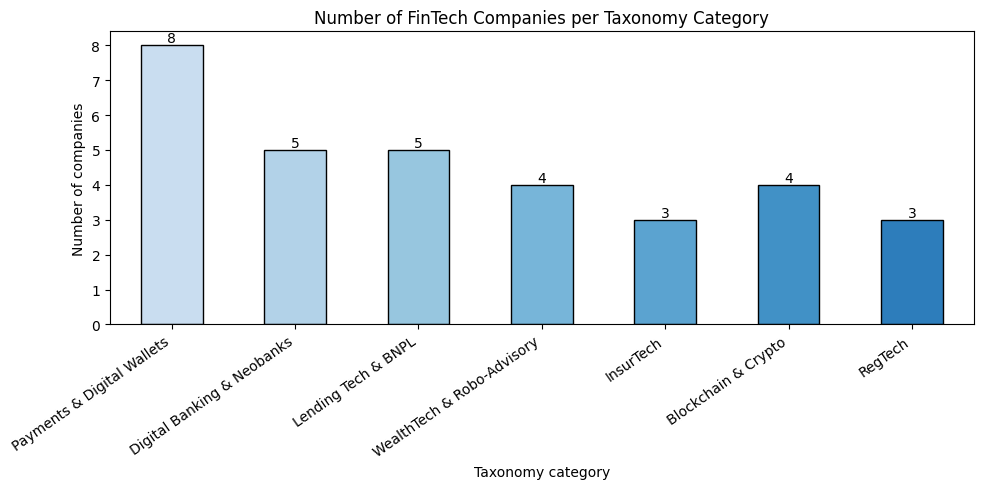

Taxonomy_Category
Payments & Digital Wallets    8
Digital Banking & Neobanks    5
Lending Tech & BNPL           5
WealthTech & Robo-Advisory    4
InsurTech                     3
Blockchain & Crypto           4
RegTech                       3
Name: count, dtype: int64

In [ ]:
counts = df["Taxonomy_Category"].value_counts().reindex(TAXONOMY)
colors = plt.cm.Blues(range(60, 60 + 20*len(counts), 20))
ax = counts.plot(kind="bar", figsize=(10,5), color=colors, edgecolor="black")
ax.set_title("Number of FinTech Companies per Taxonomy Category")
ax.set_xlabel("Taxonomy category")
ax.set_ylabel("Number of companies")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()
counts

**Interpretation:** Payments & Digital Wallets is the most represented category (8 of 32 companies), which matches what we would expect in Pakistan, where wallets and Raast-based payments are the most developed part of the ecosystem.

## 4. Reflection
The dataset's distribution supports the idea that Payments & Digital Wallets is the most developed FinTech category. Payments has the most companies, followed by Digital Banking and Lending. Pakistan shows the same pattern. Raast processed nearly Rs 50 trillion in 2025 with about 48 million users, and the State Bank reports more than 132 million registered mobile banking and wallet users by March 2026. Wallets such as JazzCash and Easypaisa grew out of the agent and mobile-money model, so payments reached the public long before other categories did. One caution is that this is a small, hand-built global sample, so it shows the typical global pattern more than it measures Pakistan directly.

InsurTech and RegTech are the clearest under-represented categories, with only three companies each. For Pakistan, a likely reason for InsurTech is market-driven: insurance penetration is low, people have limited trust in insurers and little awareness of products, and there is less digital data to price risk. For RegTech, the demand comes mainly from regulated banks and licensed payment firms, so it grows only as the number of regulated digital players and compliance requirements grows. As the five digital banks scale, demand for KYC and AML tools should rise, so I expect this gap to narrow.